In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import plotly.express as px
import torch

c:\Users\leo89\anaconda3\envs\mir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Music FM/Transformer Embedding UMAP

In [3]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine')
embedding_path = "./Embedding/MusicFM_embeddings/0" 

In [4]:
test_embedding = "./Embedding/MusicFM_embeddings/-1/0d9e2420-2188-5d46-f7a9-70953b1ed134.pt"
embedding = torch.load(test_embedding)
print(embedding.keys())
print(embedding['source_file'])
print(embedding['instrument_id'])

dict_keys(['file_id', 'source_file', 'sample_rate', 'embedding', 'instrument_id'])
Medley-solos-DB_validation-6_0d9e2420-2188-5d46-f7a9-70953b1ed134.wav
6


In [5]:
from embedding_preprocess import preprocess_embeddings

embedding_m1, id_m1, instrument_id_m1 = preprocess_embeddings(embedding_path)


In [6]:
print(embedding_m1.shape)
print(id_m1[:5])
print(instrument_id_m1[:5])

torch.Size([1000, 1024])
['Medley-solos-DB_test-4_005d3d9e-199d-5a94-f244-1758d173b2b9.wav', 'Medley-solos-DB_test-2_00a2d22d-edef-554a-f09f-c04fe172bb5e.wav', 'Medley-solos-DB_validation-3_014d0642-4796-5895-f46c-4cdbdf5193fe.wav', 'Medley-solos-DB_test-7_0162c34d-23ee-53cc-f2f7-6ac89e4d6344.wav', 'Medley-solos-DB_validation-7_01732cc0-f545-559e-f050-631f4dc1d137.wav']
['4', '2', '3', '7', '7']


In [7]:
#projection
projection = reducer.fit_transform(embedding_m1)
print(projection.shape)

(1000, 2)


In [8]:
instrument_classes = { '0' :'Clarinet', '1':'Guitar', '2':'Female Vocals', '3':'Flute', '4':'Piano', '5':'Saxophone', '6':'Trumpet', '7':'Violin' }
instrument_labels = [instrument_classes[str(i)] for i in instrument_id_m1]

In [9]:
#dataframe
df_projection = pd.DataFrame(projection, columns=['X', 'Y'])
df_projection['file_id'] = id_m1
df_projection['instrument_id'] = instrument_labels
df_projection.head()

,X,Y,file_id,instrument_id
0,7.202328,3.312975,Medley-solos-DB_test-4_005d3d9e-199d-5a94-f244...,Piano
1,1.150122,11.147989,Medley-solos-DB_test-2_00a2d22d-edef-554a-f09f...,Female Vocals
2,2.812767,6.119065,Medley-solos-DB_validation-3_014d0642-4796-589...,Flute
3,4.253810,7.014144,Medley-solos-DB_test-7_0162c34d-23ee-53cc-f2f7...,Violin
4,0.895220,5.091650,Medley-solos-DB_validation-7_01732cc0-f545-559...,Violin


In [11]:
#visualization
fig = px.scatter(df_projection, x='X', y='Y', color='instrument_id', hover_data= 'file_id', title='UMAP Projection of MusicFM Embeddings(0 semitone)', template='plotly_dark')
fig.show()

OpenL3/CNN Embedding UMAP

In [24]:
embedding_path_openl3 = "./Embedding/OpenL3_embeddings/0" 
embedding_openl3, id_openl3, instrument_id_openl3 = preprocess_embeddings(embedding_path_openl3)
projection_openl3 = reducer.fit_transform(embedding_openl3)

In [25]:
print(projection_openl3.shape)  
print(id_openl3[:5])
print(instrument_id_openl3[:5])

(1000, 2)
['Medley-solos-DB_test-4_005d3d9e-199d-5a94-f244-1758d173b2b9.wav', 'Medley-solos-DB_test-2_00a2d22d-edef-554a-f09f-c04fe172bb5e.wav', 'Medley-solos-DB_validation-3_014d0642-4796-5895-f46c-4cdbdf5193fe.wav', 'Medley-solos-DB_test-7_0162c34d-23ee-53cc-f2f7-6ac89e4d6344.wav', 'Medley-solos-DB_validation-7_01732cc0-f545-559e-f050-631f4dc1d137.wav']
['4', '2', '3', '7', '7']


In [26]:
#projection
projection_openl3 = reducer.fit_transform(embedding_openl3)
print(projection_openl3.shape)

(1000, 2)


In [27]:
#dataframe
df_projection = pd.DataFrame(projection_openl3, columns=['X', 'Y'])
df_projection['file_id'] = id_openl3
df_projection['instrument_id'] = instrument_labels
df_projection.head()

,X,Y,file_id,instrument_id
0,7.520503,-6.283981,Medley-solos-DB_test-4_005d3d9e-199d-5a94-f244...,Piano
1,-4.887473,11.983980,Medley-solos-DB_test-2_00a2d22d-edef-554a-f09f...,Female Vocals
2,1.642950,4.075841,Medley-solos-DB_validation-3_014d0642-4796-589...,Flute
3,9.973690,8.828792,Medley-solos-DB_test-7_0162c34d-23ee-53cc-f2f7...,Violin
4,2.460775,5.822157,Medley-solos-DB_validation-7_01732cc0-f545-559...,Violin


In [28]:
#visualization
fig = px.scatter(df_projection, x='X', y='Y', color='instrument_id', hover_data= 'file_id', title='UMAP Projection of MusicFM Embeddings(-1 semitone)', template='plotly_dark')
fig.show()

In [2]:
from embedding_preprocess import EmbeddingPreprocessor

embedding_path = "./Embedding/MusicFM_embeddings/0"
processor = EmbeddingPreprocessor(embedding_path, model_name="MusicFM")
processor.visualize_embeddings()

c:\Users\leo89\anaconda3\envs\mir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
embedding_path = "./Embedding/MusicFM_embeddings/1"
processor = EmbeddingPreprocessor(embedding_path)
processor.visualize_embeddings()

In [7]:
embedding_path = "./Embedding/MusicFM_embeddings/-1"
processor = EmbeddingPreprocessor(embedding_path)
processor.visualize_embeddings()

In [3]:
embedding_path_openl3 = "./Embedding/OpenL3_embeddings/0"
processor_openl3 = EmbeddingPreprocessor(embedding_path_openl3, model_name="OpenL3")
processor_openl3.visualize_embeddings()

In [5]:
embedding_path_openl3 = "./Embedding/OpenL3_embeddings/1"
processor_openl3 = EmbeddingPreprocessor(embedding_path_openl3, model_name="OpenL3")
processor_openl3.visualize_embeddings()

In [8]:
embedding_path_openl3 = "./Embedding/OpenL3_embeddings/-1"
processor_openl3 = EmbeddingPreprocessor(embedding_path_openl3, model_name="OpenL3")
processor_openl3.visualize_embeddings()

In [2]:
#classifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report
from classifier import MLPClassifier, load_embeddings, evaluate, train_classifier
from confusion_matrix import plot_confusion_matrix

INSTRUMENT_CLASSES = {
    '0': 'Clarinet', '1': 'Guitar', '2': 'Female Vocals', '3': 'Flute',
    '4': 'Piano', '5': 'Saxophone', '6': 'Trumpet', '7': 'Violin'
}
CLASS_NAMES = [INSTRUMENT_CLASSES[str(i)] for i in range(8)]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

c:\Users\leo89\anaconda3\envs\mir\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [23]:
# Load semitone 0 embeddings — change semitones list to add data augmentation e.g. [-1, 0, 1]
X_mfm, y_mfm = load_embeddings("./Embedding", "MusicFM_embeddings", semitones=[-5])
print(f"MusicFM: {X_mfm.shape}, labels: {y_mfm.unique().tolist()}")

MusicFM: torch.Size([1000, 1024]), labels: [0, 1, 2, 3, 4, 5, 6, 7]


In [24]:
model_mfm, y_true_mfm, y_pred_mfm = train_classifier(X_mfm, y_mfm, epochs=100)

Epoch   1 | val acc 0.820
Epoch  20 | val acc 0.940
Epoch  40 | val acc 0.960
Epoch  60 | val acc 0.953
Epoch  80 | val acc 0.960
Epoch 100 | val acc 0.953

Test accuracy: 0.9600


               precision    recall  f1-score   support

     Clarinet       0.89      0.89      0.89        18
       Guitar       1.00      0.91      0.95        23
Female Vocals       1.00      1.00      1.00        24
        Flute       0.90      0.95      0.92        19
        Piano       0.93      0.93      0.93        15
    Saxophone       0.93      1.00      0.96        13
      Trumpet       1.00      1.00      1.00        17
       Violin       1.00      1.00      1.00        21

     accuracy                           0.96       150
    macro avg       0.96      0.96      0.96       150
 weighted avg       0.96      0.96      0.96       150



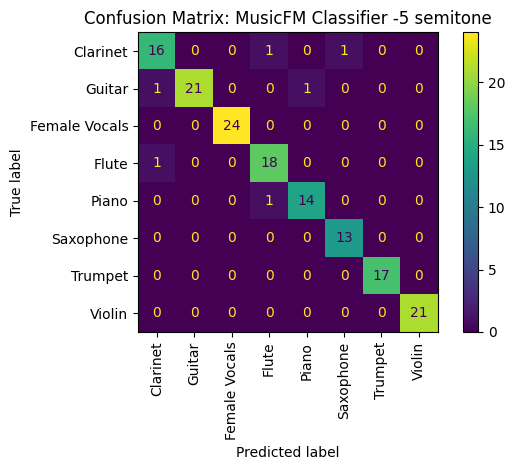

In [26]:
print(classification_report(y_true_mfm, y_pred_mfm, target_names=CLASS_NAMES))
plot_confusion_matrix(y_true_mfm.numpy(), y_pred_mfm.numpy(), CLASS_NAMES, title="MusicFM Classifier -5 semitone")

Loading OpenL3 Embedding for training

In [44]:
# Load semitone 0 embeddings — change semitones list to add data augmentation e.g. [-1, 0, 1]
X_ol3, y_ol3 = load_embeddings("./Embedding", "OpenL3_embeddings", semitones=[5])
print(f"OpenL3: {X_ol3.shape}, labels: {y_ol3.unique().tolist()}")

OpenL3: torch.Size([1000, 512]), labels: [0, 1, 2, 3, 4, 5, 6, 7]


In [45]:
model_ol3, y_true_ol3, y_pred_ol3 = train_classifier(X_ol3, y_ol3, epochs=100)

Epoch   1 | val acc 0.513
Epoch  20 | val acc 0.980
Epoch  40 | val acc 0.980
Epoch  60 | val acc 0.980
Epoch  80 | val acc 0.980
Epoch 100 | val acc 0.980

Test accuracy: 0.9933


               precision    recall  f1-score   support

     Clarinet       0.95      1.00      0.97        18
       Guitar       1.00      1.00      1.00        23
Female Vocals       1.00      1.00      1.00        24
        Flute       1.00      0.95      0.97        19
        Piano       1.00      1.00      1.00        15
    Saxophone       1.00      1.00      1.00        13
      Trumpet       1.00      1.00      1.00        17
       Violin       1.00      1.00      1.00        21

     accuracy                           0.99       150
    macro avg       0.99      0.99      0.99       150
 weighted avg       0.99      0.99      0.99       150



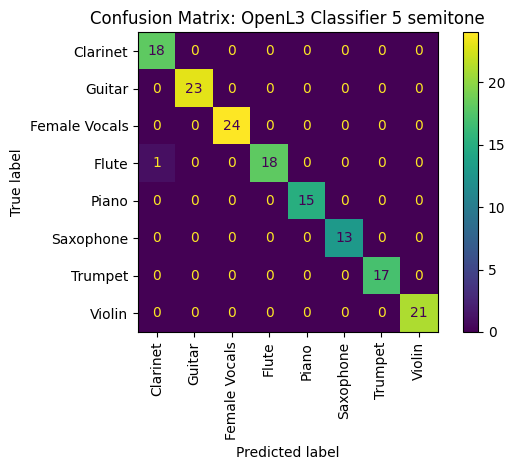

In [46]:
print(classification_report(y_true_ol3, y_pred_ol3, target_names=CLASS_NAMES))
plot_confusion_matrix(y_true_ol3.numpy(), y_pred_ol3.numpy(), CLASS_NAMES, title="OpenL3 Classifier 5 semitone")